In [8]:
from util import *
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

**Recreating figure 2.11 of Hastie, Tibshirani, and Friedman**

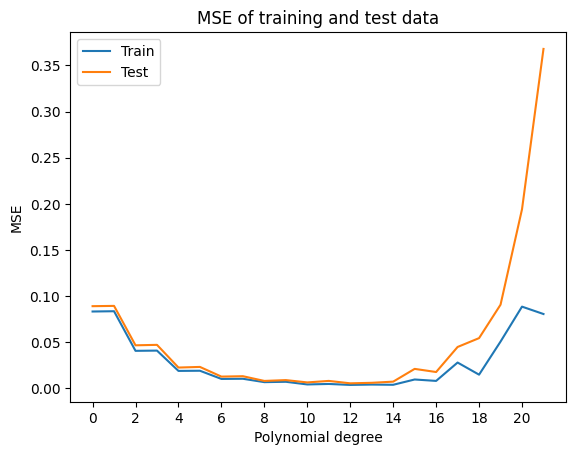

In [9]:
np.random.seed(2018)

n_points = 200
bootstraps = 1000
maxdegree = 21

noise = 0.05 * np.random.randn(n_points,1)
x = np.linspace(-1, 1, n_points).reshape(-1,1)
y = Runge(x) + noise

error_train = np.zeros(maxdegree + 1)
error_test = np.zeros(maxdegree + 1)

degrees = np.arange(0, maxdegree + 1)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25)
for degree in degrees:
    predictions_train = np.zeros((y_train.shape[0], bootstraps))
    predictions_test = np.zeros((y_test.shape[0], bootstraps))
    X_train = PolynomialFeatures(degree = degree).fit_transform(x_train)
    X_test = PolynomialFeatures(degree = degree).fit_transform(x_test)
    for i in range(bootstraps):
        x_re, y_re = resample(x_train, y_train)
        X_re = PolynomialFeatures(degree = degree).fit_transform(x_re)
        theta = OLS(X_re, y_re)
        predictions_train[:, i] = (X_train @ theta).ravel() 
        predictions_test[:, i] = (X_test @ theta).ravel() 

    # Calculate values from the predictions
    error_train[degree] = np.mean( np.mean((y_train - predictions_train) ** 2, axis = 1, keepdims = True) ) 
    error_test[degree] = np.mean( np.mean((y_test - predictions_test) ** 2, axis = 1, keepdims = True) ) 


plt.title("MSE of training and test data")
plt.plot(degrees, error_train, label = "Train")
plt.plot(degrees, error_test, label = "Test")
plt.xlabel("Polynomial degree")
plt.ylabel("MSE")
plt.xticks(degrees[::2])
plt.legend()

**Bias-variance analysis of Runge function**

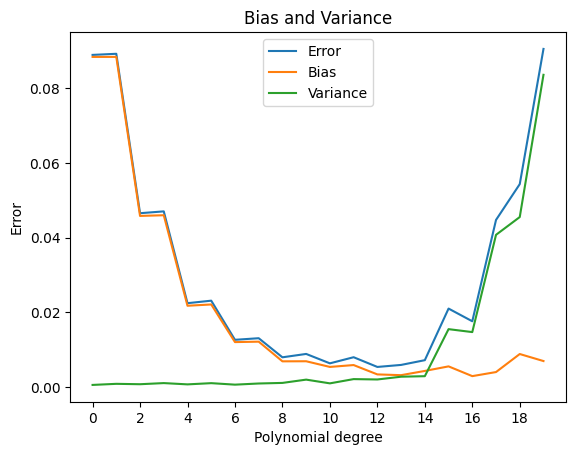

In [10]:
np.random.seed(2018)
n_points = 200
bootstraps = 1000
maxdegree = 20

noise = 0.05 * np.random.randn(n_points,1)
x = np.linspace(-1, 1, n_points).reshape(-1,1)
y = Runge(x) + noise

error = np.zeros(maxdegree)
bias = np.zeros(maxdegree)
variance = np.zeros(maxdegree)
polydegree = np.zeros(maxdegree)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25)

for degree in range(maxdegree):
    y_pred = np.empty((y_test.shape[0], bootstraps))
    X_test = PolynomialFeatures(degree = degree).fit_transform(x_test)
    for i in range(bootstraps):
        x_, y_ = resample(x_train, y_train)
        X_train_resample = PolynomialFeatures(degree=degree).fit_transform(x_)
        
        theta = OLS(X_train_resample, y_)
        y_pred[:, i] = (X_test @ theta).ravel()

    polydegree[degree] = degree
    error[degree] = np.mean( np.mean((y_test - y_pred)**2, axis=1, keepdims=True) )
    bias[degree] = np.mean( (y_test - np.mean(y_pred, axis=1, keepdims=True))**2 )
    variance[degree] = np.mean( np.var(y_pred, axis=1, keepdims=True) )

# Save error for use in part H
# Ensure Results folder exists
np.save('Results/partG_error.npy', error)


# Plotting          
plt.title("Bias and Variance")
plt.xlabel("Polynomial degree")
plt.ylabel("Error")
plt.plot(polydegree, error, label='Error')
plt.plot(polydegree, bias, label='Bias')
plt.plot(polydegree, variance, label='Variance')
plt.xticks(polydegree[::2])
plt.legend()
plt.show()


**Plotting data points and polynomial degree error**

In [11]:
np.random.seed(2018)
bootstraps = 1000
maxdegree = 20


degrees = np.arange(0, maxdegree + 1, 1)
datapoints = np.arange(200, 301, 10)

error = np.zeros((datapoints.shape[0],degrees.shape[0]))
print("Degrees computed:")
for degree in degrees:
    print(degree, end = "-")
    for j,n_data in enumerate(datapoints):
        noise = 0.05 * np.random.randn(n_data,1)
        x = np.linspace(-1, 1, n_data).reshape(-1,1)
        y = Runge(x) + noise
        x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25)
        
        y_pred = np.empty((y_test.shape[0], bootstraps))
        X_test = PolynomialFeatures(degree = degree).fit_transform(x_test)
        for i in range(bootstraps):
            x_, y_ = resample(x_train, y_train)
            X_train_resample = PolynomialFeatures(degree=degree).fit_transform(x_)
            theta = OLS(X_train_resample, y_)
            y_pred[:, i] = (X_test @ theta).ravel()

        error[j][degree] = np.mean(np.mean( (y_test - y_pred) ** 2, axis=1, keepdims=True))

Degrees computed:
0-1-2-3-4-5-6-7-8-9-10-11-12-13-14-15-16-17-18-19-20-

**Plotting**

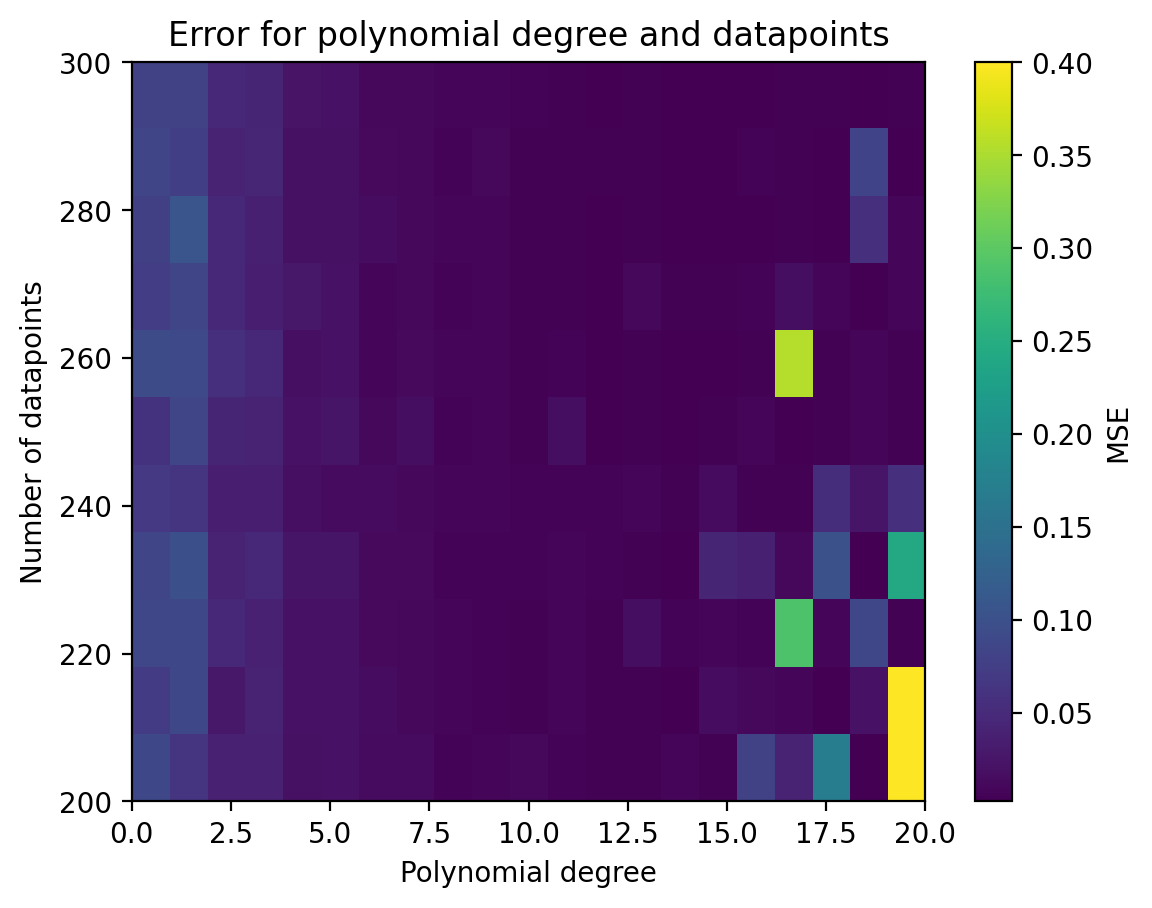

In [12]:
plt.figure(dpi = 200)
plt.imshow(error, aspect = "auto", extent = (degrees.min(), degrees.max(), datapoints.min(), datapoints.max()), origin="lower", vmax=0.4)
plt.colorbar(label = "MSE")
plt.title("Error for polynomial degree and datapoints")
plt.xlabel("Polynomial degree")
plt.ylabel("Number of datapoints")
plt.show()